# Exploring FASERnu neutrino data

FASER is an experiment at CERN that studies **neutrinos** produced by the Large Hadron
Collider. Its detector, FASERnu, is a stack of ~700 photographic films. When a particle
passes through, it leaves a track in the emulsion.

When a neutrino hits a nucleus in the detector it produces a spray of charged particles
all starting from one point. That point is called a **vertex**, and the tracks coming out
of it are the **primary tracks**.

The problem: a neutrino is not the only thing that can make a vertex like this. A
**neutral hadron** (a neutron, a Lambda, a K-zero) is also electrically neutral, so it
also leaves no track coming *in*, and it also makes a spray of particles going *out*.
Under a microscope the two look very similar. Telling them apart is the job in this
notebook's follow-up, and your job here is to look at the data and get a feel for it.

- **Signal** = a real neutrino interaction
- **Background** = a neutral hadron interaction

Each row of `vertices.csv` is one vertex, already summarised from its tracks.

## 1. Setting up

If you have not installed the packages yet, see the `README.md` in the folder above.
These four lines import the tools we need. It is normal for the first import to take a
few seconds.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the plots a bit bigger and easier to read
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["font.size"] = 11

/home/simon/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-46lv9k2x because there was an issue with the default path (/home/simon/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 2. Loading the data

`pd.read_csv` reads a CSV file into a **DataFrame**, which is pandas' name for a table.

In [2]:
df = pd.read_csv("data/vertices.csv")

print(f"The table has {len(df)} rows and {len(df.columns)} columns.")
df.head()

The table has 268898 rows and 35 columns.


,interaction,weight,n_vtrk,n_vtrk_100mrad,n_vtrk_ip5,n_vtrk_ip5_100mrad,slope_mean,slope_max,slope_std,delta_phi_mean,...,dphi_p,r90,n_vtrk_ippos3um,n_vtrk_nseg5,leadtrk_slope,leadtrk_pt,has_electron_candidate,has_muon_candidate,a_sum,pt_sum
0,background,0.012076,16,13,12,10,0.044510,0.234557,0.063800,1.19585,...,0.691528,5,9,11,0.009818,1.093480,True,False,5.94956,19.52690
1,background,0.012076,12,12,11,11,0.020772,0.068745,0.019130,1.31445,...,0.259512,5,10,12,0.004763,0.681239,False,False,3.63459,6.39293
2,background,0.012076,16,12,13,11,0.074647,0.230627,0.072782,1.49407,...,1.000440,5,11,12,0.003270,0.189398,False,False,3.11276,4.04239
3,background,0.012076,11,9,10,9,0.037693,0.145570,0.049010,1.46417,...,3.107230,7,10,11,0.005100,0.646455,False,False,3.01539,10.40670
4,background,0.012076,6,4,6,4,0.082637,0.284230,0.108143,1.52539,...,2.082130,4,5,4,0.087922,3.599170,False,True,2.29045,11.70510


`.head()` shows the first five rows. Some useful first commands:

- `df.shape` - how many rows and columns
- `df.columns` - the column names
- `df.describe()` - minimum, maximum, mean and quartiles of every numeric column

Try them. `describe()` is wide, so scroll sideways.

In [3]:
df.describe()

,weight,n_vtrk,n_vtrk_100mrad,n_vtrk_ip5,n_vtrk_ip5_100mrad,slope_mean,slope_max,slope_std,delta_phi_mean,delta_phi_max,...,e_em_sum,dphi_unit,dphi_p,r90,n_vtrk_ippos3um,n_vtrk_nseg5,leadtrk_slope,leadtrk_pt,a_sum,pt_sum
count,268898.000000,268898.000000,268898.000000,268898.000000,268898.000000,268898.000000,268898.000000,268898.000000,268898.000000,268898.000000,...,268898.000000,268898.000000,265901.000000,268898.000000,268898.000000,268898.000000,268898.000000,268898.000000,268898.000000,268898.000000
mean,0.006875,9.486497,7.384521,8.411398,6.896507,0.068451,0.203417,0.065829,1.501318,2.747581,...,528.131194,1.524981,1.716344,4.144456,6.985980,7.937694,0.028224,2.109829,2.841117,10.285585
std,0.005554,4.726734,3.752120,4.049601,3.443232,0.036358,0.117521,0.039140,0.553322,0.495394,...,453.143643,1.013786,1.051930,2.772247,3.506096,3.884287,0.036201,2.560254,1.659778,7.688967
min,0.001002,2.000000,0.000000,0.000000,0.000000,0.007414,0.029980,0.000002,0.001629,0.001629,...,55.842600,0.000011,0.000020,0.000000,0.000000,0.000000,0.000100,0.004643,0.000024,0.007365
25%,0.002648,6.000000,5.000000,5.000000,4.000000,0.041384,0.105664,0.034284,1.145960,2.654262,...,279.723250,0.565391,0.707064,2.000000,4.000000,5.000000,0.009872,0.721616,1.622003,4.881177
50%,0.005506,9.000000,7.000000,8.000000,6.000000,0.062654,0.183439,0.059839,1.437540,2.917440,...,434.553000,1.454830,1.783650,4.000000,6.000000,7.000000,0.017101,1.306870,2.577105,8.579280
75%,0.012076,12.000000,10.000000,11.000000,9.000000,0.088256,0.284449,0.091151,1.759370,3.052800,...,640.139500,2.499770,2.778150,6.000000,9.000000,10.000000,0.031566,2.420247,3.782172,13.764300
max,0.018107,43.000000,38.000000,35.000000,31.000000,0.502472,0.527719,0.343903,3.141570,3.141590,...,18754.000000,3.141590,3.141590,24.000000,31.000000,36.000000,0.511770,52.930100,19.068100,269.542000


## 3. What kind of interaction is each row?

The `interaction` column says what actually happened. We know this because the data is
**simulated**, so the true answer was recorded when it was generated. In real data we
would not have this column - that is the whole point of building a classifier.

The five values mean:

| value | meaning |
|---|---|
| `numuCC` | a muon neutrino, charged-current (it turned into a muon) |
| `nueCC` | an electron neutrino, charged-current (it turned into an electron) |
| `nutauCC` | a tau neutrino, charged-current (rare!) |
| `NC` | any neutrino, neutral-current (the neutrino bounced off and kept going) |
| `background` | a neutral hadron - **not** a neutrino |

In [4]:
df["interaction"].value_counts()

interaction
background    162949
numuCC         65375
NC             22630
nueCC          17356
nutauCC          588
Name: count, dtype: int64

For classification we usually want a simple yes/no answer rather than five categories.
There is no ready-made column for this, on purpose - it is one line to make:

In [5]:
# True for any kind of neutrino, False for a neutral hadron
is_signal = df["interaction"] != "background"

print(f"signal     : {is_signal.sum()}")
print(f"background : {(~is_signal).sum()}")

signal     : 105949
background : 162949


## 4. A warning about the `weight` column

**Never use `weight` as an input to a classifier.**

`weight` says how many real interactions each simulated one represents. It depends only
on *which simulation file* the row came from - and the signal and background came from
different files. So the weight gives away the answer:

In [6]:
# Every weight value belongs to exactly one class - it is a perfect give-away
df.groupby("weight")["interaction"].unique()

weight
0.001002    [NC, nueCC, numuCC, nutauCC]
0.001969             [numuCC, NC, nueCC]
0.002648             [numuCC, nueCC, NC]
0.003093                    [background]
0.005506                    [background]
0.007828                    [background]
0.012076                    [background]
0.013133                    [background]
0.018107                    [background]
Name: interaction, dtype: object

So what is `weight` *for*? It converts "number of simulated events" into "number of
events we expect to actually see in the real detector". We will use it in section 7.

## 5. Your first histogram

A **histogram** counts how many rows fall into each range of values. Let's look at
`n_vtrk`, the number of primary tracks coming out of the vertex.

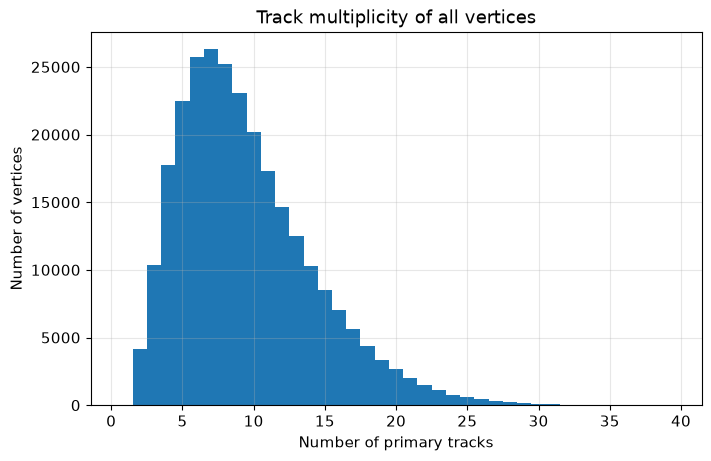

In [7]:
fig, ax = plt.subplots(layout="constrained")

ax.hist(df["n_vtrk"], bins=np.arange(0.5, 40.5, 1))

ax.set_xlabel("Number of primary tracks")
ax.set_ylabel("Number of vertices")
ax.set_title("Track multiplicity of all vertices")
ax.grid(alpha=0.3)
plt.show()

Always label your axes. A plot without labels tells the reader nothing.

`bins=np.arange(0.5, 40.5, 1)` puts the bin edges at 0.5, 1.5, 2.5 ... so that each whole
number sits in the middle of its own bin. That matters for counting things.

## 6. Comparing signal and background

This is the important plot. If the two classes look different in some variable, a
classifier can use that variable. If they look identical, it cannot.

`density=True` rescales each histogram so its total area is 1. Without it the taller
histogram would just be the one with more rows, which tells us nothing.

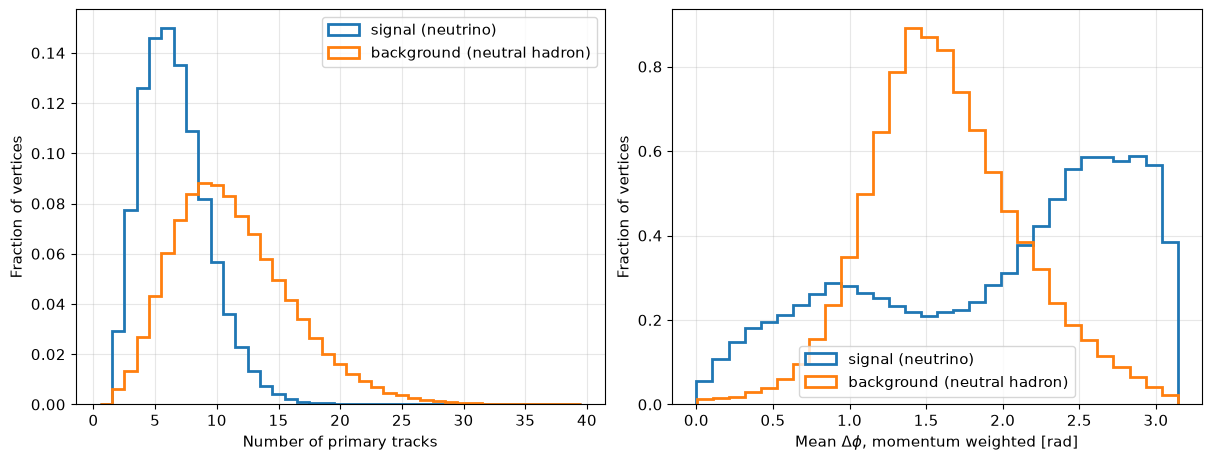

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")

# n_vtrk counts whole tracks, so its bins must be centred on whole numbers.
# delta_phi is continuous, so any reasonable number of bins works.
for ax, column, label, bins in [
    (axes[0], "n_vtrk", "Number of primary tracks", np.arange(0.5, 40.5, 1)),
    (axes[1], "delta_phi_p_mean", r"Mean $\Delta\phi$, momentum weighted [rad]", 30),
]:
    ax.hist(df.loc[is_signal, column].dropna(), bins=bins, density=True,
            histtype="step", linewidth=2, label="signal (neutrino)")
    ax.hist(df.loc[~is_signal, column].dropna(), bins=bins, density=True,
            histtype="step", linewidth=2, label="background (neutral hadron)")
    ax.set_xlabel(label)
    ax.set_ylabel("Fraction of vertices")
    ax.legend()
    ax.grid(alpha=0.3)

plt.show()


Two real physics effects are visible here:

**Left:** neutral hadrons produce *more* tracks than neutrinos. A hadron interacts via
the strong force, which is messier and sprays out more particles.

**Right:** `delta_phi_p_mean` measures how **back-to-back** the vertex is. Imagine looking
down the beam pipe: in a neutrino interaction the outgoing lepton flies one way and all
the other particles recoil the other way, so the angle between them is close to
$\pi$ (180 degrees). A neutral hadron has no lepton, so its tracks are spread more evenly
and the angle is smaller.

Try swapping in other columns - `p_mean`, `n_kinks`, `ip_pos_max`, `slope_max` - and see
which ones separate the two classes well.

## 7. Using the weights

The simulation contains roughly equal numbers of signal and background, but that is **not**
what the real experiment sees. Multiplying by `weight` tells us the real expectation.

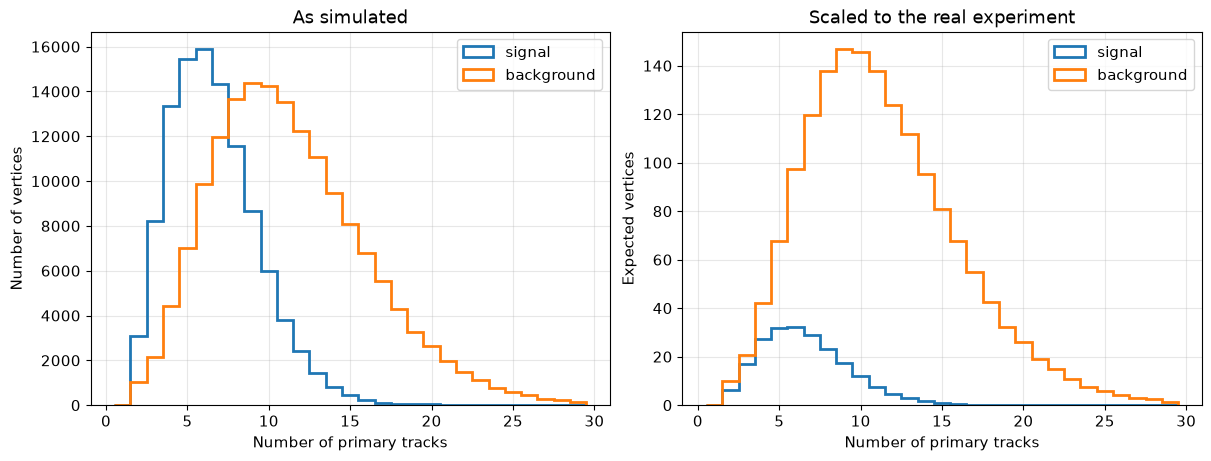

As simulated :   105949 signal,   162949 background
Real expectation :    215 signal,   1634 background


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
bins = np.arange(0.5, 30.5, 1)

for ax, weights, title in [
    (axes[0], None, "As simulated"),
    (axes[1], df["weight"], "Scaled to the real experiment"),
]:
    ax.hist(df.loc[is_signal, "n_vtrk"], bins=bins, histtype="step", linewidth=2,
            weights=None if weights is None else weights[is_signal], label="signal")
    ax.hist(df.loc[~is_signal, "n_vtrk"], bins=bins, histtype="step", linewidth=2,
            weights=None if weights is None else weights[~is_signal], label="background")
    ax.set_xlabel("Number of primary tracks")
    ax.set_ylabel("Number of vertices" if weights is None else "Expected vertices")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.show()

print(f"As simulated : {is_signal.sum():>8} signal, {(~is_signal).sum():>8} background")
print(f"Real expectation : {df.loc[is_signal, 'weight'].sum():>6.0f} signal, "
      f"{df.loc[~is_signal, 'weight'].sum():>6.0f} background")

This is the single most important plot in the notebook. As simulated the classes are
almost balanced. In the real experiment the background outnumbers the signal about
**8 to 1**. A classifier that looks good on the simulated numbers can still be useless in
practice, because every mistake on a background event costs eight times as much.

## 8. Two variables at once

A histogram shows one variable. To see how two variables behave together, use a
**hexbin** plot: the plane is tiled with hexagons and each is coloured by how many points
fall in it.

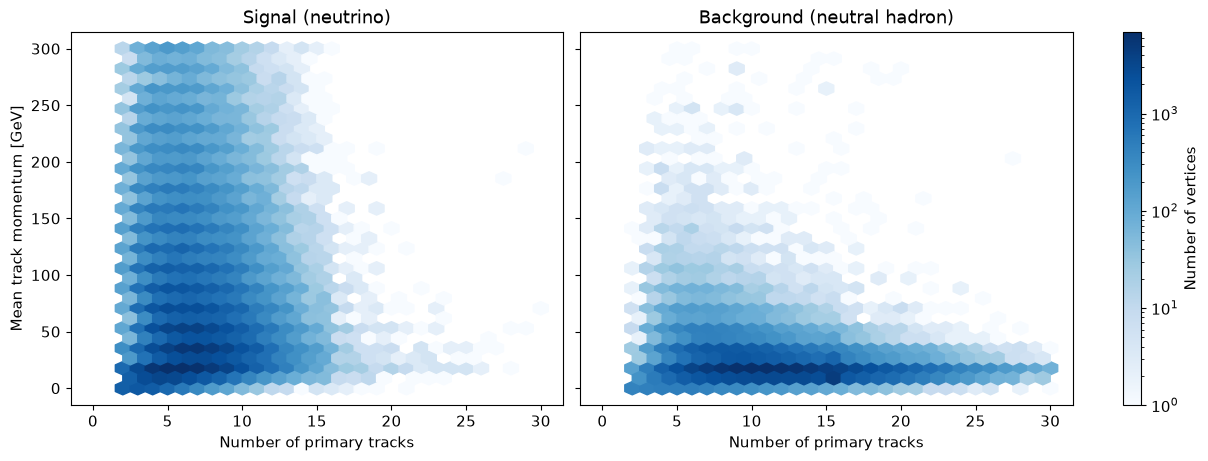

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained", sharey=True)

for ax, mask, title in [
    (axes[0], is_signal, "Signal (neutrino)"),
    (axes[1], ~is_signal, "Background (neutral hadron)"),
]:
    subset = df[mask]
    # bins="log" colours by the logarithm of the count. Without it the one busiest
    # hexagon is dark and everything else is nearly white.
    image = ax.hexbin(subset["n_vtrk"], subset["p_mean"], gridsize=30, bins="log",
                      extent=(0, 30, 0, 300), cmap="Blues", mincnt=1)
    ax.set_xlabel("Number of primary tracks")
    ax.set_title(title)

axes[0].set_ylabel("Mean track momentum [GeV]")
fig.colorbar(image, ax=axes, label="Number of vertices")
plt.show()


Signal sits towards the upper left: fewer tracks, but each carrying more momentum.
Background sits lower right: many tracks sharing the energy between them.

## 9. Which variables say the same thing?

If two columns are strongly correlated they carry nearly the same information, and
including both adds little. `.corr()` computes the correlation between every pair.

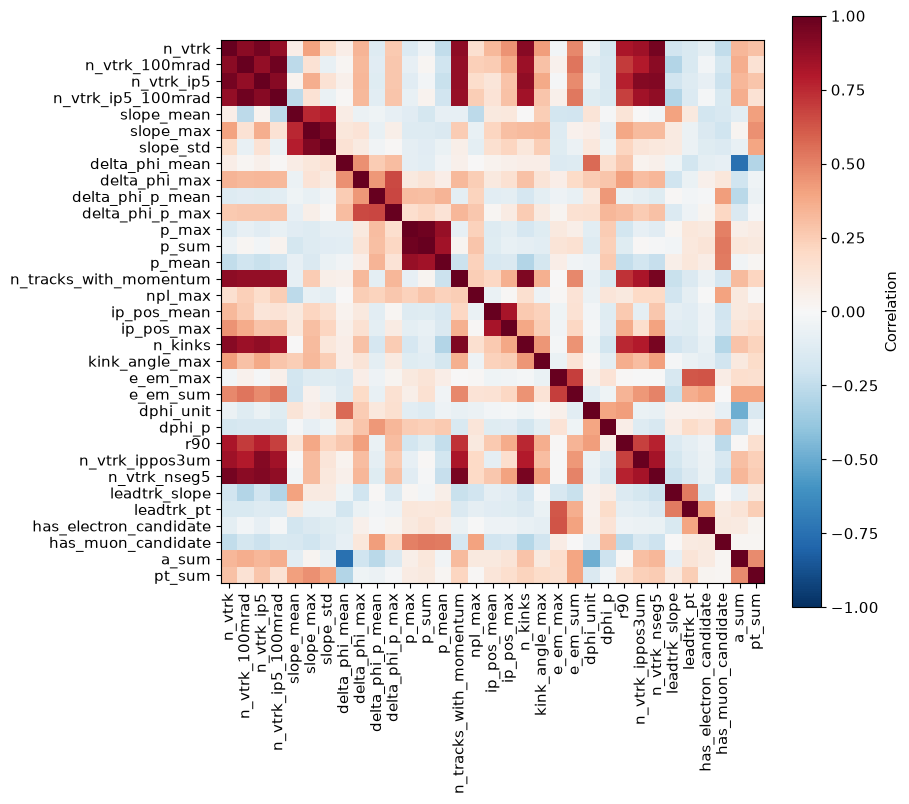

In [11]:
features = [c for c in df.columns if c not in ("interaction", "weight")]
correlation = df[features].corr()

fig, ax = plt.subplots(figsize=(9, 8), layout="constrained")
image = ax.imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(features)), features, rotation=90)
ax.set_yticks(range(len(features)), features)
fig.colorbar(image, ax=ax, label="Correlation")
plt.show()

Deep red means "these two go up together", deep blue means "when one goes up the other
goes down". Notice the block of `n_vtrk`, `n_vtrk_ip5`, `n_vtrk_100mrad` and `n_kinks` in
the top left - they are all counting roughly the same thing.

## 10. Missing values

Not every quantity could be measured for every vertex. Missing entries are `NaN`
("not a number"), and pandas skips them in `mean()`, `hist()` and so on.

In [12]:
missing = df.isna().mean() * 100
missing[missing > 0].round(2).sort_values(ascending=False)

delta_phi_p_mean    1.81
delta_phi_p_max     1.81
dphi_p              1.11
kink_angle_max      0.51
p_max               0.21
p_mean              0.21
p_sum               0.21
dtype: float64

Where these come from:

- **`p_max`, `p_sum`, `p_mean`** - momentum can only be measured for a track long enough
  to be followed through many films. About a quarter of tracks are too short, and in a
  few vertices *no* track could be measured. `n_tracks_with_momentum` tells you how many
  went into the average.
- **`delta_phi_p_mean`, `delta_phi_p_max`** - these need momenta, so they need at least
  two measurable tracks.
- **`kink_angle_max`** - only defined if a kink (a sudden change of direction, meaning a
  particle decayed) was found at all.
- **`dphi_p`** - weights the other tracks by their momentum, so it is missing when none
  of them has one.

Missing data is never random. Always ask *why* something is missing before deciding what
to do about it.

## Where to go next

You have seen that signal and background differ in several variables. The next step is to
let a computer combine them into a single decision - that is
**machine learning**, and it is the subject of the follow-up notebook.

Before that, try these:

1. Plot every feature as a signal/background overlay. Which three separate best?
2. Does `nueCC` look different from `numuCC`? (Filter with `df[df["interaction"] == "nueCC"]`.)
3. `e_em_sum` barely differs between the classes. Can you see why from its histogram?
4. Recreate the section 7 comparison using `p_mean` instead of `n_vtrk`.

### Documentation

Everything used here is documented online. These are the official references:

- **pandas** - tables, `read_csv`, filtering, `groupby`: <https://pandas.pydata.org/docs/>
  (start with the [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html) guide)
- **NumPy** - arrays and numerical maths: <https://numpy.org/doc/stable/>
  (start with [NumPy: the absolute basics for beginners](https://numpy.org/doc/stable/user/absolute_beginners.html))
- **Matplotlib** - plotting: <https://matplotlib.org/stable/>
  (the [pyplot tutorial](https://matplotlib.org/stable/tutorials/pyplot.html) and the
  [example gallery](https://matplotlib.org/stable/gallery/index.html) are the most useful pages)
- **scikit-learn** - machine learning: <https://scikit-learn.org/stable/>
  (start with [An introduction to machine learning](https://scikit-learn.org/stable/tutorial/basic/tutorial.html))